# TUTORIAL: Class EchoStateNetwork

Introduction to the `tools_ML.EchoStateNetwork` class. The echo state network class is based on Raca & Racca Magri (2021).

In this tutorial we will use an EchoStateNetwork to model the Lorenz 63 system. 


In [1]:
from tools_ML import EchoStateNetwork
# help(EchoStateNetwork)

# Create training data from the Lorenz 63 model

In [2]:
from utils import create_Lorenz63_dataset

# Create a Lorenz63 dataset with noise
dataset = create_Lorenz63_dataset(noise_level=0.02, num_lyap_times = 300)

clean_data = dataset['clean_data']
noisy_data = dataset['noisy_data']
t = dataset['t']
N_lyap = dataset['N_lyap']

Loaded case


### Separate data into train, validation and test datasets and visualize

In [3]:
N_transient = 15 * N_lyap
N_val = 5 * N_lyap
N_train = 60 * N_lyap - N_val 
N_test = noisy_data.shape[0]-sum((N_train,N_val,N_transient))


train_val_data = noisy_data[N_transient:N_transient+N_train+2*N_val]

test_data = noisy_data[N_transient+N_train+N_val:N_transient+N_train+N_val+N_test]
test_data_clean = clean_data[N_transient+N_train+N_val:N_transient+N_train+N_val+N_test] # Truth to compare the tests


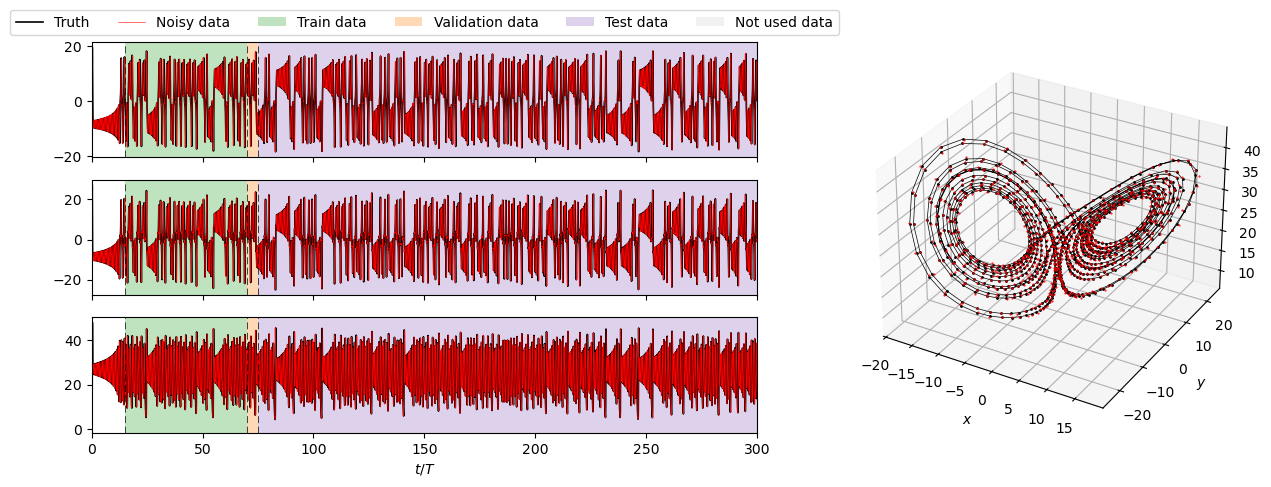

In [5]:
from plotting import plot_train_dataset

dt = t[1] - t[0]
t_lyap = N_lyap * dt

split_times = [tt / N_lyap for tt in [N_transient, N_train, N_val, N_test]]

plot_train_dataset(clean_data, noisy_data, t/t_lyap, *split_times)

# Initialize the ESN
NB: Different initializations result in different Wout.

In [6]:
import numpy as np

ESN_params = dict(N_wash=10,  # Number of washout steps i.e., open-loop initialization
                  N_units=50,  # Number of neurons 
                  upsample=2, # We want the ESN to predict t + upsample * dt 
                  t_train=N_train * dt,  # Training time
                  t_val=N_val * dt, # Validation time
                  t_test=2*N_val * dt, # Validation time
                  # Training-specific input_parameters
                  N_func_evals=30,
                  N_grid=5,
                  noise=1e-2,
                  Win_type='sparse',
                  N_folds=8,
                  N_split=5,
                  # Hyperparameter optimization ranges
                  rho_range=(.2, .95),
                  sigma_in_range=(-2, 2),
                  tikh_range=[1E-9, 1E-10],
                #   random_initialization=True
                  )


# Initialize ESN class
ESN_init = EchoStateNetwork(y=np.zeros((3,1)), 
                       dt=dt, 
                       **ESN_params)


# Train the ESN
The result of the ESN training is the output matrix. We can train the network to input the full state or partial observations.

## a) Full observability


seed 0 	 Optimal hyperparameters: [np.float64(0.2), np.float64(1.0)], 1e-09, MSE: -0.9606376295672073

 ----------------- HYPERPARAMETER SEARCH ------------------
 5x5 grid and 5 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 MSE val 
1	 2.000e-01	 1.000e-02	 1.000e-09	 -0.8976
2	 2.000e-01	 1.000e-01	 1.000e-09	 -0.1537
3	 2.000e-01	 1.000e+00	 1.000e-09	 -0.4516
4	 2.000e-01	 1.000e+01	 1.000e-09	 -0.9606
5	 2.000e-01	 1.000e+02	 1.000e-09	 -0.7803
6	 3.875e-01	 1.000e-02	 1.000e-09	 -0.4376
7	 3.875e-01	 1.000e-01	 1.000e-09	 3.2800
8	 3.875e-01	 1.000e+00	 1.000e-09	 -0.7695
9	 3.875e-01	 1.000e+01	 1.000e-09	 -0.8936
10	 3.875e-01	 1.000e+02	 1.000e-09	 -0.7829
11	 5.750e-01	 1.000e-02	 1.000e-09	 -0.4382
12	 5.750e-01	 1.000e-01	 1.000e-09	 3.9314
13	 5.750e-01	 1.000e+00	 1.000e-09	 -0.5245
14	 5.750e-01	 1.000e+01	 1.000e-09	 -0.9364
15	 5.750e-01	 1.000e+02	 1.000e-09	 -0.7794
16	 7.625e-01	 1.000e-02	 1.000e-09	 -0.4571
17	 7.625e-01	 1.000e-01	 1.000e-09	 3.7477
1

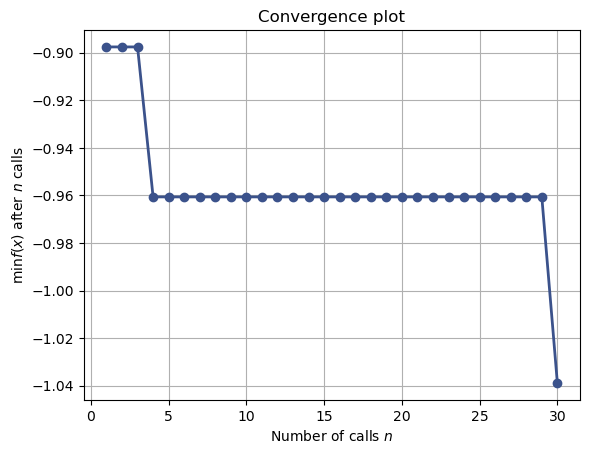

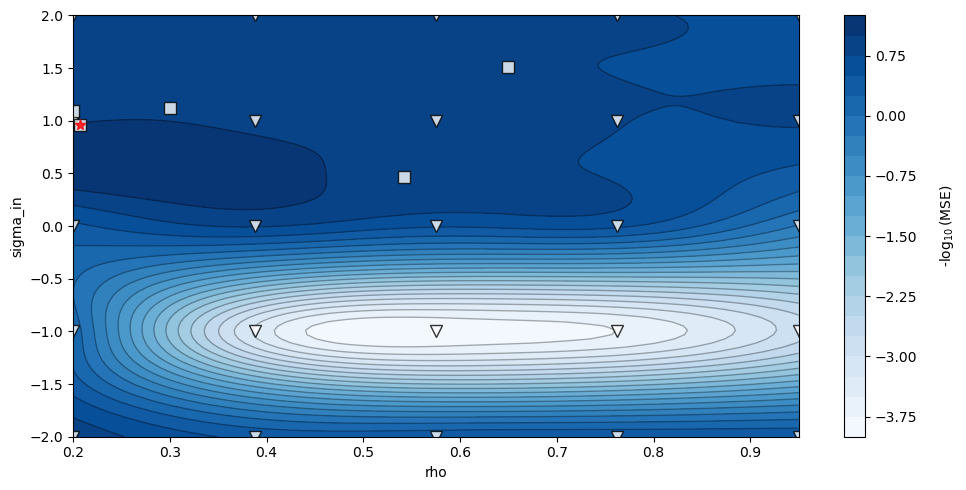

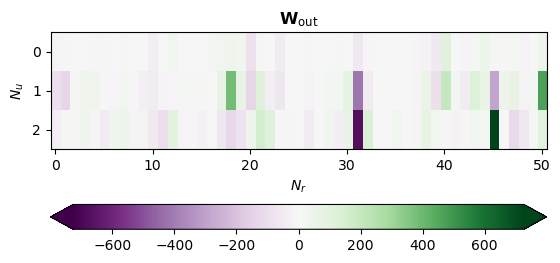

In [7]:
seeds= [0, 252]
for seed in seeds:
    ESN = ESN_init.copy()
    ESN.seed_W = seed
    ESN.train(train_val_data, 
              add_noise=True, 
              plot_training=seed==seeds[-1]
             )

### Test the long-term prediction

Running test for L=0 with data shapes U: (2063, 3), Y: (2063, 3)
Overall tests min, max and mean MSE in 2 tests = -0.6658, -0.6658, -0.6658.


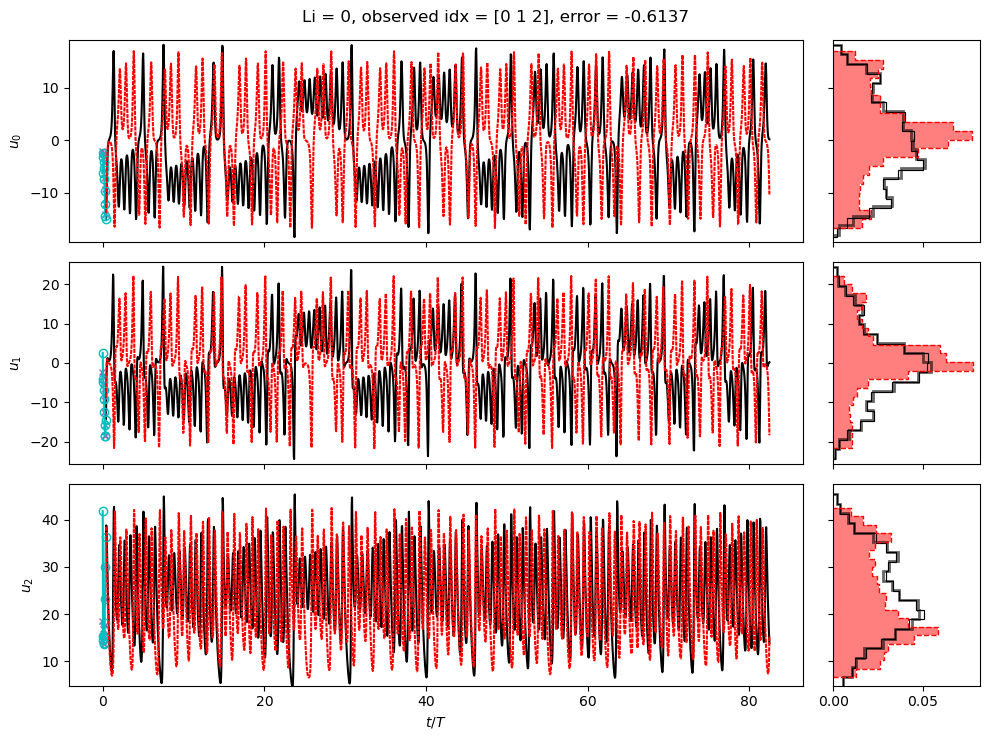

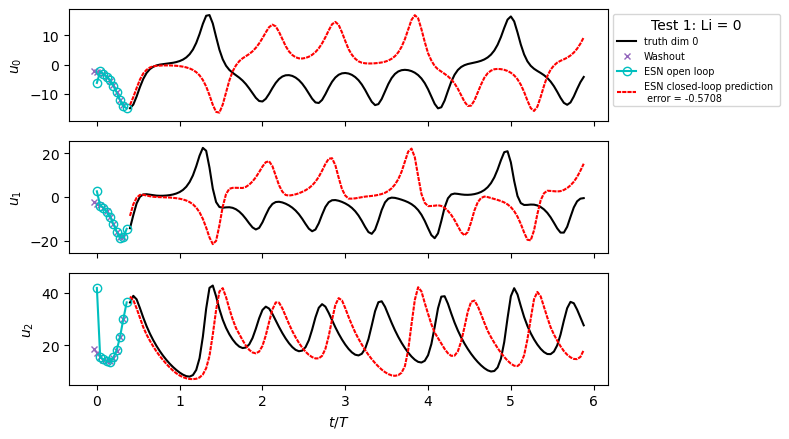

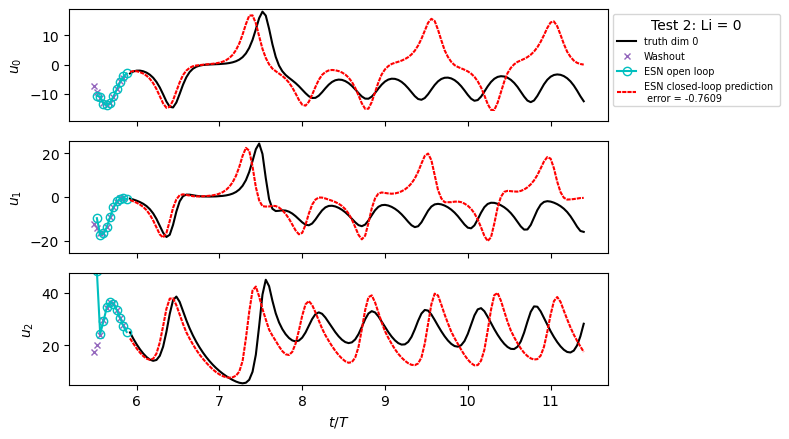

In [8]:

test_data = noisy_data[-(N_transient+N_train+N_val):]
test_data_clean = clean_data[-(N_transient+N_train+N_val):]  # Truth to compare the tests

upsample_test_data = test_data[::ESN.upsample].copy() # Input
upsample_test_data_clean = test_data_clean[::ESN.upsample].copy() # Truth

ESN.run_test(U_test=upsample_test_data, 
             Y_test=upsample_test_data_clean, 
             long_term=True,
             short_term=True,
             max_short_tests=2,
             );

## b) Partial observability


 ----------------- HYPERPARAMETER SEARCH ------------------
 5x5 grid and 5 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 MSE val 
1	 4.000e-01	 1.000e-02	 1.000e-09	 -0.8473
2	 4.000e-01	 1.000e-01	 1.000e-09	 -0.3852
3	 4.000e-01	 1.000e+00	 1.000e-09	 -0.6786
4	 4.000e-01	 1.000e+01	 1.000e-09	 -0.7444
5	 4.000e-01	 1.000e+02	 1.000e-09	 -0.6696
6	 5.375e-01	 1.000e-02	 1.000e-09	 -0.5767
7	 5.375e-01	 1.000e-01	 1.000e-09	 -0.3803
8	 5.375e-01	 1.000e+00	 1.000e-09	 -0.7167
9	 5.375e-01	 1.000e+01	 1.000e-09	 -0.7143
10	 5.375e-01	 1.000e+02	 1.000e-09	 -0.6800
11	 6.750e-01	 1.000e-02	 1.000e-09	 -0.6057
12	 6.750e-01	 1.000e-01	 1.000e-09	 0.5586
13	 6.750e-01	 1.000e+00	 1.000e-09	 -0.7192
14	 6.750e-01	 1.000e+01	 1.000e-09	 -0.7517
15	 6.750e-01	 1.000e+02	 1.000e-10	 -0.6829
16	 8.125e-01	 1.000e-02	 1.000e-09	 -0.6109
17	 8.125e-01	 1.000e-01	 1.000e-09	 3.1971
18	 8.125e-01	 1.000e+00	 1.000e-09	 -0.7058
19	 8.125e-01	 1.000e+01	 1.000e-09	 -0.7748
20	 8.125e-0

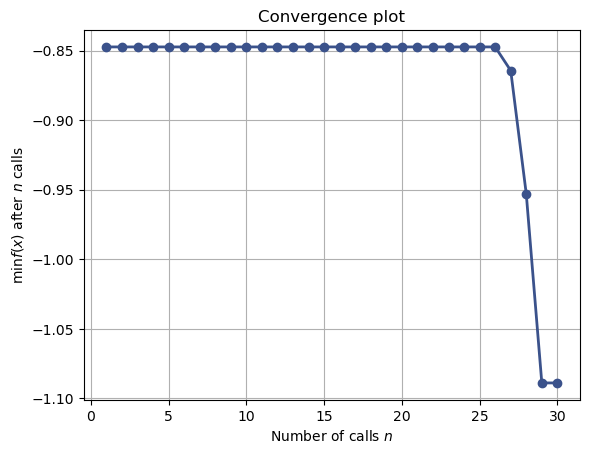

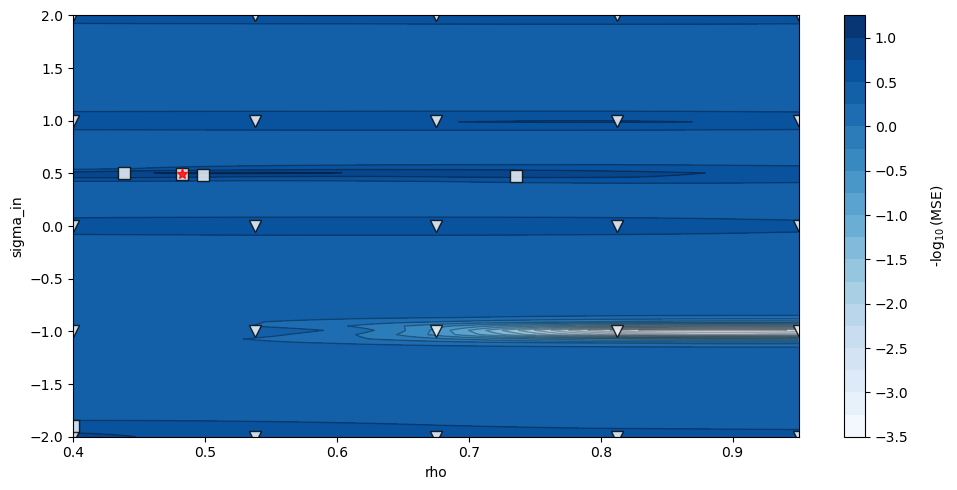

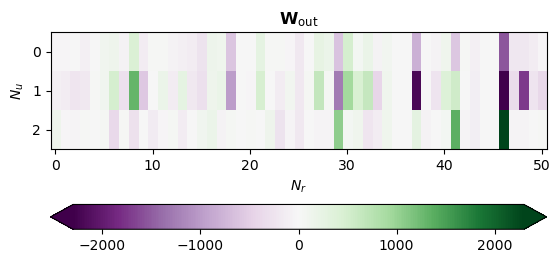

In [9]:

# Define Echo state network input_parameters

ESN_partial = ESN_init.copy()
ESN_partial.N_folds = 16
ESN_partial.rho_range = (0.4, 0.95)

# Set the observed dimensions
ESN_partial.observed_idx = [0, 2]


ESN_partial.train(train_val_data, 
          add_noise=True, 
          plot_training=True,
         )

Running test for L=0 with data shapes U: (2063, 2), Y: (2063, 3)
Overall tests min, max and mean MSE in 2 tests = -0.7607, -0.7607, -0.7607.


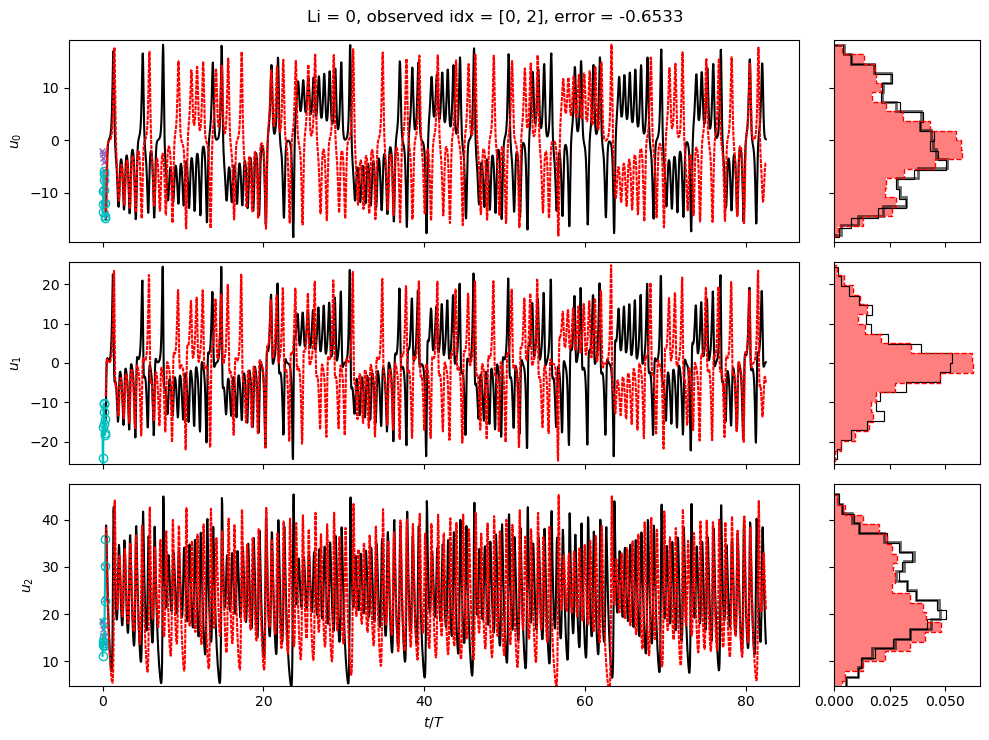

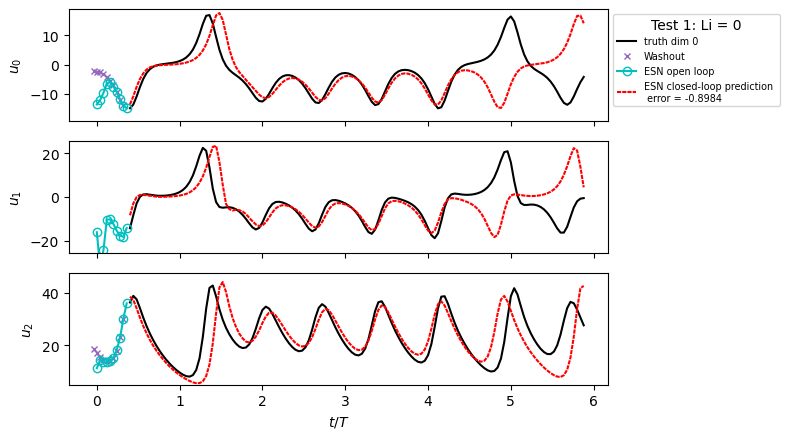

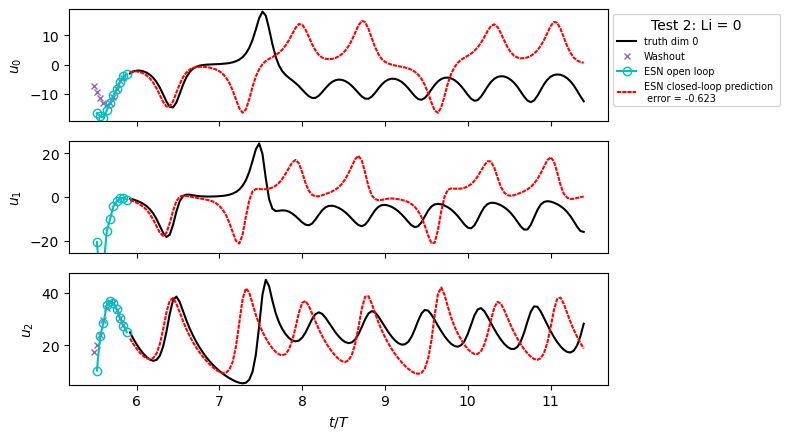

In [10]:

ESN_partial.run_test(U_test=upsample_test_data[:, ESN_partial.observed_idx], 
                    Y_test=upsample_test_data_clean, 
                    long_term=True,
                    max_short_tests=2,
                    );


If prediction is much worse, try increasing the length of the timeseries or number of folds.